4, 14). Nedan ser vi en början till modellering av ett mycket berömt dataset kopplat till blommor. Läs på vad datasetet innebär och genomför ett komplett
ML-flöde. Börja med att göra ett grundläggande flöde som fungerar, därefter kan du om du önskar försöka förbättra resultatet.


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [18]:
# Load & visa data
# This code is merely executed to see the description and target names in a smooth way
iris = load_iris()
print(iris.DESCR)
print(iris.target_names)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [ ]:
# X innehåller features, y innehåller klasserna. Det betyder att det är ett klassificeringsproblem.
# Här används as_frame=True för att få X och y som dataframes istället för numpy-arrays, vilket gör det enklare att hantera dem
X, y = load_iris(return_X_y=True, as_frame=True)

# Only choose two variables for the modelling to keep it simple
X = X[['sepal length (cm)', 'sepal width (cm)']]

# Valideringsdatan kommer användas för att jämföra två modeller senare.
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.3, random_state=36)

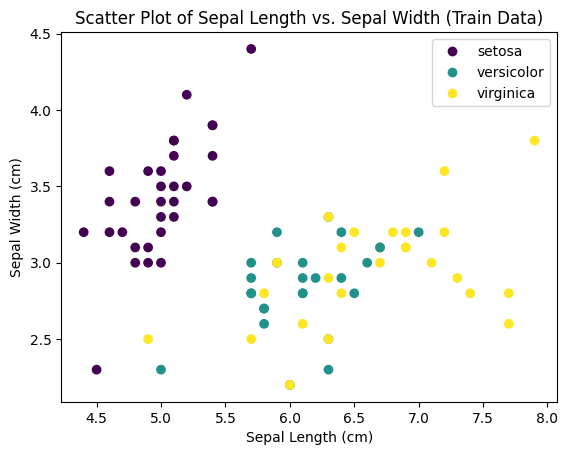

In [20]:
# Här visas en scatter plot av två valda features i träningsdatan och färgerna representerar de tre klasserna.
# Vi ser här att versicolor och virginica är svårare att separera än setosa.

classes = ['setosa', 'versicolor', 'virginica']
scatter = plt.scatter(X_train['sepal length (cm)'], X_train['sepal width (cm)'], c=y_train)

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Scatter Plot of Sepal Length vs. Sepal Width (Train Data)')
plt.legend(handles=scatter.legend_elements()[0], labels=classes)


In [21]:
X_train.head()

,sepal length (cm),sepal width (cm)
72,6.3,2.5
62,6.0,2.2
74,6.4,2.9
19,5.1,3.8
93,5.0,2.3


In [22]:
y_train.head()

72    1
62    1
74    1
19    0
93    1
Name: target, dtype: int64

In [ ]:
# I träningsdatan-y, finss det mer observationer av klassen setosa än de andra två klasserna.
y_train.value_counts()

target
0    32
1    26
2    26
Name: count, dtype: int64

In [24]:
# Jag ville se antal värde i varje klass i y innan det separerades i train, val och test.
y.value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [25]:
# Nu tränas en Logistic Regression modell som är en linjär modell som används för klassificering.
# Den försöker hitta en linje som bäst separerar klasserna.
# Vi "fit" modellen på träningsdatan och sedan gör vi prediktioner på valideringsdatan. Den utvärderas senare med classification_report och confusion matrix.

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
log_reg_pred = log_reg.predict(X_val)

In [28]:
# Nu tränas en Decision Tree modell som är en icke-linjär modell.
# Istället för att välja trädets djup manuellt, använder jag GridSearch för att testa GridSearch i koden.
# GridSearch testar olika hyperparametrar och använder cross validation för att välja det som ger bäst resultat på valideringsdatan.

tree_clf = DecisionTreeClassifier()

# 5-fold cross validation och % korrekt klassificering som mått.
h_params = {'max_depth':(None, 1, 2, 3, 5, 10)}
grid_tree = GridSearchCV(tree_clf, h_params, cv=5, scoring='accuracy')

grid_tree.fit(X_train, y_train)
tree_pred = grid_tree.predict(X_val)

print("Best parameters for Decision Tree:", grid_tree.best_params_)
print("------------------------------------------------------------")
pd.DataFrame(grid_tree.cv_results_)

Best parameters for Decision Tree: {'max_depth': 2}
------------------------------------------------------------


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001399,4.903365e-04,0.001201,4.027141e-04,None,{'max_depth': None},0.588235,0.647059,0.764706,0.764706,0.6250,0.677941,0.073294,4
1,0.001001,2.759895e-06,0.001201,4.001868e-04,1,{'max_depth': 1},0.647059,0.705882,0.705882,0.647059,0.5625,0.653676,0.052634,6
2,0.000800,3.999711e-04,0.000902,4.918643e-04,2,{'max_depth': 2},0.764706,0.647059,0.823529,0.882353,0.6250,0.748529,0.099349,1
3,0.000803,4.012902e-04,0.000999,9.887906e-07,3,{'max_depth': 3},0.764706,0.647059,0.823529,0.882353,0.5625,0.736029,0.116548,2
4,0.001000,4.156970e-07,0.001000,1.907349e-07,5,{'max_depth': 5},0.705882,0.647059,0.823529,0.823529,0.5625,0.712500,0.101471,3
5,0.000800,4.002349e-04,0.000799,3.997340e-04,10,{'max_depth': 10},0.529412,0.647059,0.764706,0.764706,0.6250,0.666176,0.089646,5


Text(0.5, 1.0, 'Decision Tree')

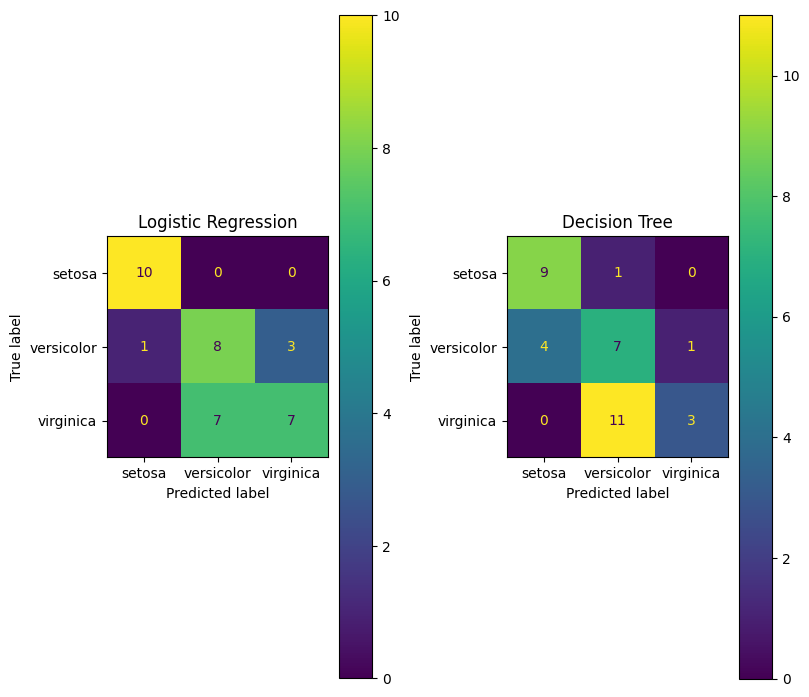

In [ ]:
# Nu väljer vi den bästa modellen bgenom att jämföra dem i confusion matrix och classification report.
cm1 = confusion_matrix(y_val, log_reg_pred)
cm2 = confusion_matrix(y_val, tree_pred)

# Titelarna visas i confusion matrix för att underlätta jämförelsen av modellerna.
# Och vi ser att Logistic Regression presterar bättre här.

fig, axs = plt.subplots(1, 2, figsize = (8, 7), layout='constrained')
ConfusionMatrixDisplay(cm1, display_labels = classes).plot(ax=axs[0])
axs[0].set_title("Logistic Regression")
ConfusionMatrixDisplay(cm2, display_labels = classes).plot(ax=axs[1])
axs[1].set_title("Decision Tree")

In [ ]:
# Vi ser här att Logistic Regression har högre accuracy, bättre balans mellan precision och recall än Decision Tree.
# För detta detaset funkar en linjär modell bättre än en icke-linjär modell.

print("Classification report: Logistic Regression")
print(classification_report(y_val, log_reg_pred, target_names=classes))

print("--------------------------------------------------------------")
print("Classification report: Decision Tree")
print(classification_report(y_val, tree_pred, target_names=classes))

Classification report: Logistic Regression
              precision    recall  f1-score   support

      setosa       0.91      1.00      0.95        10
  versicolor       0.53      0.67      0.59        12
   virginica       0.70      0.50      0.58        14

    accuracy                           0.69        36
   macro avg       0.71      0.72      0.71        36
weighted avg       0.70      0.69      0.69        36

--------------------------------------------------------------
Classification report: Decision Tree
              precision    recall  f1-score   support

      setosa       0.69      0.90      0.78        10
  versicolor       0.37      0.58      0.45        12
   virginica       0.75      0.21      0.33        14

    accuracy                           0.53        36
   macro avg       0.60      0.57      0.52        36
weighted avg       0.61      0.53      0.50        36



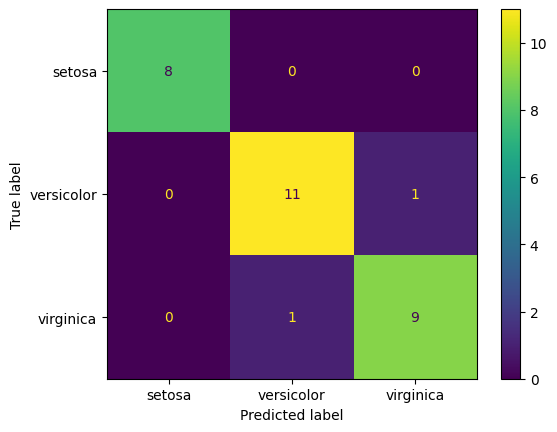

In [ ]:
# Nu tränas om den valda modellen (Logistic Regression) på hela träningsdatan (train & val) och sedan utvärderas den på testdatan.
# Vi ser att modellen presterar bättre nu när den tränas på mer data.

log_reg.fit(X_train_full, y_train_full)
pred_test = log_reg.predict(X_test)

cm_test = confusion_matrix(y_test, pred_test)
ConfusionMatrixDisplay(cm_test, display_labels = classes).plot()

In [ ]:
# Här ser vi också att modellen presterar bättre nu.
# Datasetet är inte så stort, så det gör stor skillnad att träna på mer data.

print(classification_report(y_test, pred_test, target_names=classes))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.92      0.92      0.92        12
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.94        30
weighted avg       0.93      0.93      0.93        30

